In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


### Load dataset

In [2]:
att=pd.read_csv("../data/attendance_current_month.csv")

In [3]:
cls=pd.read_csv("../data/classroom.csv")

In [4]:
att.head()

,student_id,student_name,course,batch_id,1-Apr,2-Apr,3-Apr,4-Apr,5-Apr,6-Apr,...,26-Apr,27-Apr,28-Apr,29-Apr,30-Apr,Total Days,Present,Absent,Attendance %,Status
0,STU0001,Kiran,MERN Stack Development,B04,P,A,P,H,H,P,...,H,NaN,NaN,NaN,NaN,5,3,2,60,Warning
1,STU0002,Tanya,Data Science with Python,B02,A,P,P,H,H,A,...,H,NaN,NaN,NaN,NaN,5,3,2,60,Warning
2,STU0003,Faisal,Data Science with Python,A03,A,P,P,H,H,P,...,H,NaN,NaN,NaN,NaN,5,4,1,80,Regular
3,STU0004,Ajay,Python Full Stack Development,A07,P,P,A,H,H,P,...,H,NaN,NaN,NaN,NaN,5,3,2,60,Warning
4,STU0005,Rahul,MERN Stack Development,A01,P,P,P,H,H,P,...,H,NaN,NaN,NaN,NaN,5,5,0,100,Excellent


In [5]:
cls.head()

,CID,Occupancy,10:00-12:00,12:00-02:00,02:30-04:30,04:30-05:30
0,C001,20,AI-A10,MERN-A10,MERN-A09,MERN-B10
1,C002,20,BA-A10,PHP-A10,PHP-A09,PHP-B10
2,C003,20,DS-A10,Python-A10,Python-A09,Python-B10
3,C004,20,DevOps-A10,React-A10,React-A09,React-B10
4,C005,20,Flutter-A10,UIUX-A10,UIUX-A09,UIUX-B10


In [6]:
att.columns

Index(['student_id', 'student_name', 'course', 'batch_id', '1-Apr', '2-Apr',
       '3-Apr', '4-Apr', '5-Apr', '6-Apr', '7-Apr', '8-Apr', '9-Apr', '10-Apr',
       '11-Apr', '12-Apr', '13-Apr', '14-Apr', '15-Apr', '16-Apr', '17-Apr',
       '18-Apr', '19-Apr', '20-Apr', '21-Apr', '22-Apr', '23-Apr', '24-Apr',
       '25-Apr', '26-Apr', '27-Apr', '28-Apr', '29-Apr', '30-Apr',
       'Total Days', 'Present', 'Absent', 'Attendance %', 'Status'],
      dtype='object')

In [7]:
cls.columns

Index(['CID', 'Occupancy', '10:00-12:00', '12:00-02:00', '02:30-04:30',
       '04:30-05:30'],
      dtype='object')

In [8]:
att['Status'].unique()

array(['Warning', 'Regular', 'Excellent', 'Critical'], dtype=object)

In [9]:
att['course'].unique()

array(['MERN Stack Development', 'Data Science with Python',
       'Python Full Stack Development', 'DevOps',
       'React Frontend Developer', 'Business Analytics',
       'Flutter Development', 'Cyber Security', 'UI/UX Design'],
      dtype=object)

In [10]:
att.duplicated().sum()

np.int64(0)

In [11]:
cls.duplicated().sum()

np.int64(0)

In [12]:
att.isna().sum()

student_id        0
student_name      0
course            0
batch_id          0
1-Apr             0
2-Apr             0
3-Apr             0
4-Apr             0
5-Apr             0
6-Apr             0
7-Apr             0
8-Apr           200
9-Apr           200
10-Apr          200
11-Apr            0
12-Apr            0
13-Apr          200
14-Apr          200
15-Apr          200
16-Apr          200
17-Apr          200
18-Apr            0
19-Apr            0
20-Apr          200
21-Apr          200
22-Apr          200
23-Apr          200
24-Apr          200
25-Apr            0
26-Apr            0
27-Apr          200
28-Apr          200
29-Apr          200
30-Apr          200
Total Days        0
Present           0
Absent            0
Attendance %      0
Status            0
dtype: int64

In [13]:
cls.isna().sum()

CID            0
Occupancy      0
10:00-12:00    0
12:00-02:00    0
02:30-04:30    0
04:30-05:30    0
dtype: int64

## Visualisation

### KPI's

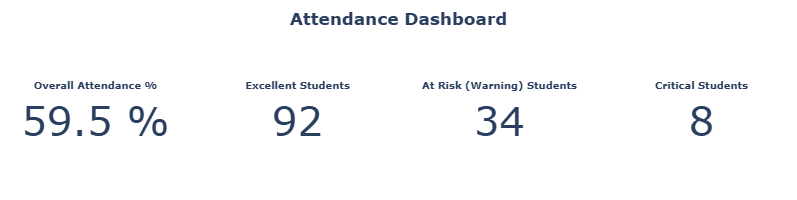

In [14]:
# --- Data ---
status_counts = att['Status'].value_counts()

excellent = int(status_counts.get('Excellent', 0))
warning   = int(status_counts.get('Warning', 0))
critical  = int(status_counts.get('Critical', 0))

total_students = len(att)

# Example: overall attendance % (adjust if needed)
overall_attendance = round((excellent*1 + warning*0.7 + critical*0.4) / total_students * 100, 1)

# --- Create subplots ---
fig = go.Figure()

# Helper to create KPI
def add_kpi(value, title, x_pos, suffix=""):
    fig.add_trace(go.Indicator(
        mode="number",
        value=value,
        title={"text": f"<b>{title}</b>"},
        number={
            "font": {"size": 40},
            "suffix": suffix
        },
        domain={'x': x_pos, 'y': [0, 1]}
    ))

# Add KPIs
add_kpi(overall_attendance, "Overall Attendance %", [0.00, 0.22]," %")
add_kpi(excellent, "Excellent Students", [0.26, 0.48])
add_kpi(warning, "At Risk (Warning) Students", [0.52, 0.74])
add_kpi(critical, "Critical Students", [0.78, 1.00])

# Layout
fig.update_layout(
    title_text="<b>Attendance Dashboard</b>",
    title_x=0.5,
    height=200,
    margin=dict(t=50, b=10, l=10, r=10,
    )
    
)

fig.show()

### Attendence status

In [15]:
status_colors= {
    'Excellent': '#2ECC71',
    'Regular':   '#3498DB',
    'Warning':   '#F39C12',
    'Critical':  '#E74C3C',
}

In [16]:
status_counts = (att['Status']
                 .value_counts()
                 .reset_index()
                 .rename(columns={'count':'Count'}))


In [17]:
status_counts 

,Status,Count
0,Excellent,92
1,Regular,66
2,Warning,34
3,Critical,8


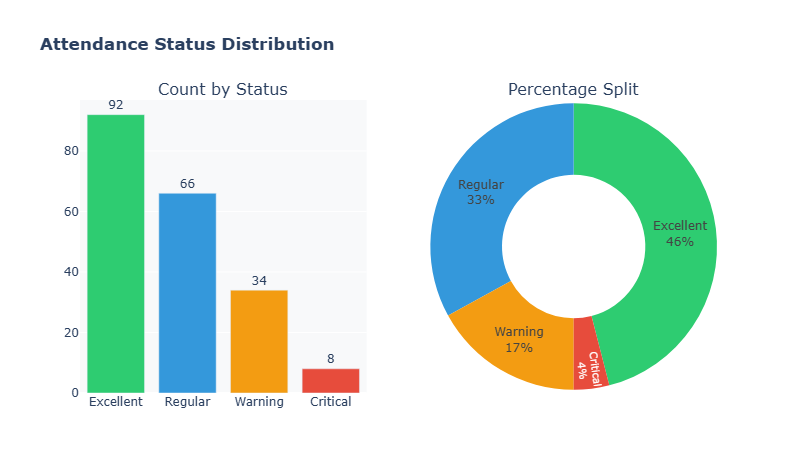

In [18]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Count by Status', 'Percentage Split'],
    specs=[[{'type':'bar'}, {'type':'pie'}]]
)

# Bar
bar_fig = px.bar(
    status_counts,
    x='Status',
    y='Count',
    color_discrete_sequence=[['#2ECC71','#3498DB','#F39C12','#E74C3C']],
    text='Count'
)

bar_fig.update_traces(
    textposition='outside',
    showlegend=False
)

fig.add_trace(bar_fig.data[0], row=1, col=1)

# Pie
pie_fig = px.pie(
    status_counts,
    names='Status',
    values='Count',
    color='Status',
    color_discrete_map=status_colors,
    hole=0.5
)

pie_fig.update_traces(
    textinfo='label+percent',
    textposition='inside'
)

fig.add_trace(pie_fig.data[0], row=1, col=2)

# Layout
fig.update_layout(
    title='<b>Attendance Status Distribution</b>',
    height=473,
    showlegend=False,
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white'
)

fig.show()

### Course x Attendance

In [19]:
course_status = (att.groupby(['course','Status'])
                 .size().reset_index(name='Count'))

In [20]:
course_status

,course,Status,Count
0,Business Analytics,Excellent,2
1,Business Analytics,Regular,2
2,Cyber Security,Critical,1
3,Cyber Security,Excellent,3
4,Cyber Security,Regular,3
5,Data Science with Python,Critical,1
6,Data Science with Python,Excellent,37
7,Data Science with Python,Regular,25
8,Data Science with Python,Warning,10
9,DevOps,Critical,1


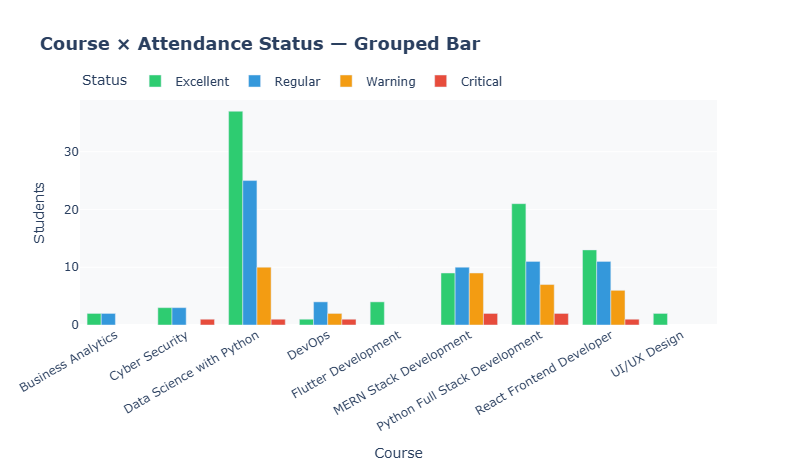

In [21]:
fig = px.bar(
    course_status,
    x='course',
    y='Count',
    color='Status',
    barmode='group',
    color_discrete_map=status_colors,
    title='<b>Course × Attendance Status — Grouped Bar</b>',
    labels={'course': 'Course', 'Count': 'Students'},
    category_orders={'Status': ['Excellent','Regular','Warning','Critical']}
)

fig.update_layout(
    xaxis_tickangle=-30,
    height=470,
    title_font_size=18,
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

### Daily attendence trend

In [22]:
# Step 1: extract April columns
day_cols = [c for c in att.columns if '-Apr' in c]

# Step 2: calculate daily %
daily = {}
for d in day_cols:
    col = att[d].astype(str).str.strip().str.upper()
    working = col.isin(['P','A'])
    if working.sum() > 0:
        daily[d] = round((col == 'P').sum() / working.sum() * 100, 1)

# Step 3: create dataframe
daily_df = pd.DataFrame({
    'Day': list(daily.keys()),
    'Pct': list(daily.values())
})

# Step 4: sort
daily_df['DayNum'] = daily_df['Day'].str.replace('-Apr','').astype(int)
daily_df = daily_df.sort_values('DayNum')

# Step 5: mean
mean_pct = daily_df['Pct'].mean()

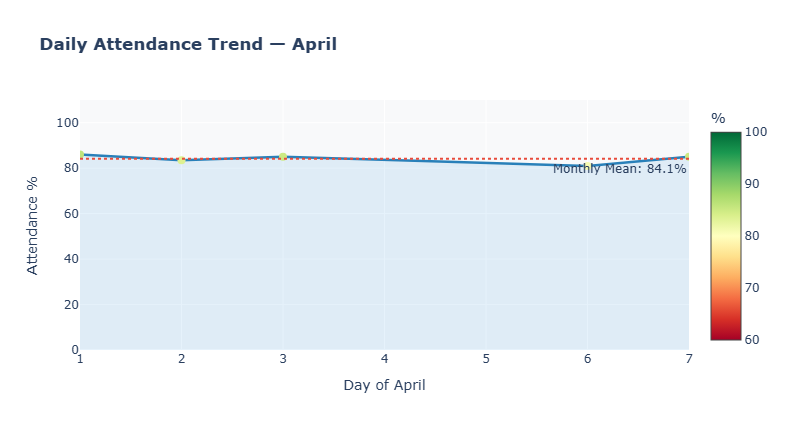

In [23]:
# Line chart
fig = px.line(
    daily_df,
    x='DayNum',
    y='Pct',
    markers=True,
    title='<b>Daily Attendance Trend — April</b>'
)

# Color markers based on percentage
fig.update_traces(
    line=dict(color='#2980B9', width=2.5),
    marker=dict(
        size=8,
        color=daily_df['Pct'],
        colorscale='RdYlGn',
        cmin=60,
        cmax=100,
        showscale=True,
        colorbar_title='%'
    ),
    fill='tozeroy',
    fillcolor='rgba(52,152,219,0.12)',
)

# Add mean line (same as GO)
fig.add_hline(
    y=mean_pct,
    line_dash='dot',
    line_color='#E74C3C',
    annotation_text=f'Monthly Mean: {mean_pct:.1f}%',
    annotation_position='bottom right'
)

# Layout
fig.update_layout(
    xaxis_title='Day of April',
    yaxis_title='Attendance %',
    yaxis_range=[0, 110],
    height=430,
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white'
)

fig.show()

In [24]:
batch_status = (att.groupby(['batch_id','Status'])
                .size().unstack(fill_value=0))
for col in ['Excellent','Regular','Warning','Critical']:
    if col not in batch_status.columns:
        batch_status[col] = 0
batch_status = batch_status[['Excellent','Regular','Warning','Critical']]

In [25]:
batch_status

Status,Excellent,Regular,Warning,Critical
batch_id,,,,
A01,6,5,3,1
A02,3,2,1,0
A03,9,5,1,0
A04,5,6,4,0
A05,6,1,1,1
A06,6,3,2,0
A07,5,2,3,1
A08,7,4,7,1
B01,9,4,1,0


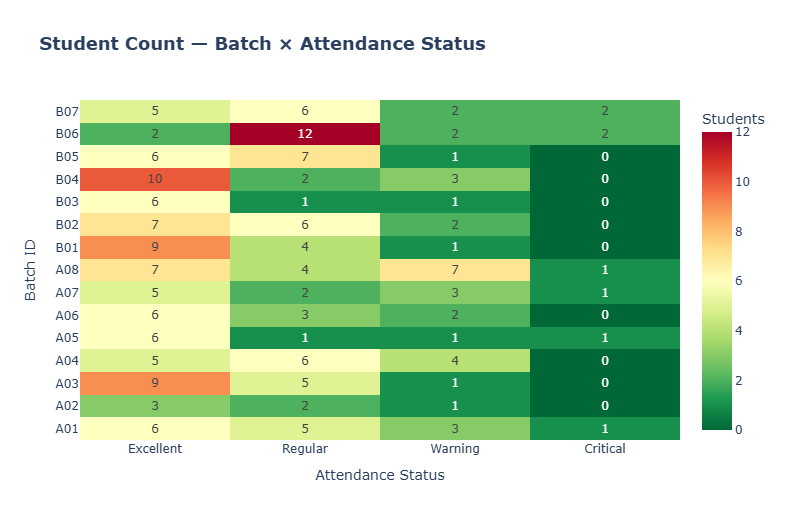

In [26]:
fig = go.Figure(go.Heatmap(
    z=batch_status.values,
    x=batch_status.columns.tolist(),
    y=batch_status.index.tolist(),
    colorscale='RdYlGn',
    reversescale=True,
    text=batch_status.values,
    texttemplate='%{text}',
    textfont_size=12,
    colorbar_title='Students'
))

fig.update_layout(
    title_text='<b>Student Count — Batch × Attendance Status</b>',
    title_font_size=18,
    xaxis_title='Attendance Status',
    yaxis_title='Batch ID',
    height=520,
    paper_bgcolor='white'
)
fig.show()

In [27]:
top_absent = att.sort_values(by='Absent', ascending=False).head(10)

In [28]:
top_absent = top_absent.groupby(
    ['student_name', 'Status'], as_index=False
).agg({
    'Absent': 'sum',
    'course': 'first',
    'batch_id': 'first',
    'Attendance %': 'first',
    'Present': 'sum'
})

In [29]:
top_absent = top_absent.sort_values(by='Absent', ascending=True)

In [30]:
top_absent

,student_name,Status,Absent,course,batch_id,Attendance %,Present
0,Aisha,Warning,2,Python Full Stack Development,A06,60,3
5,Manoj,Warning,2,MERN Stack Development,A08,60,3
1,Aman,Critical,3,React Frontend Developer,A08,40,2
2,Divya,Critical,3,Python Full Stack Development,B06,40,2
3,Faisal,Critical,3,Data Science with Python,A07,40,2
6,Meena,Critical,3,MERN Stack Development,B07,40,2
7,Pooja,Critical,3,MERN Stack Development,B07,40,2
4,Irfan,Critical,4,Python Full Stack Development,B06,20,1
8,Zara,Critical,6,DevOps,A01,40,4


In [31]:

fig = px.bar(
    top_absent,
    y='student_name',
    x='Absent',
    orientation='h',
    color='Status',
    color_discrete_map=status_colors,
    text='Absent',
    hover_data={'course': True, 'batch_id': True,
                'Attendance %': True, 'Present': True},
    labels={'student_name': 'Student', 'Absent': 'Days Absent'},
    title='<b>Top 10 Most Absent Students</b>'
)

fig.update_traces(textposition='outside')
fig.update_layout(
    height=450,
    title_font_size=18,
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    xaxis_range=[0, top_absent['Absent'].max() + 5]
)
fig.show()

In [32]:
course_pa = (att.groupby('course')[['Present','Absent']]
             .mean()
             .round(1)
             .reset_index()
             .sort_values('Present', ascending=False))

fig = go.Figure()
fig.add_trace(go.Bar(
    name='Present',
    x=course_pa['course'],
    y=course_pa['Present'],
    marker_color='#2ECC71',
    hovertemplate='<b>%{x}</b><br>Avg Present: %{y} days<extra></extra>'
))
fig.add_trace(go.Bar(
    name='Absent',
    x=course_pa['course'],
    y=course_pa['Absent'],
    marker_color='#E74C3C',
    hovertemplate='<b>%{x}</b><br>Avg Absent: %{y} days<extra></extra>'
))

fig.update_layout(
    barmode='stack',
    title_text='<b>Average Present vs Absent Days by Course</b>',
    title_font_size=18,
    xaxis_tickangle=-30,
    yaxis_title='Average Days',
    height=470,
    plot_bgcolor='#F8F9FA',
    paper_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()